# Chapter 4 Companion Notebook  
## VaR, CVaR and Downside Risk Assessment

This notebook is the Python companion for **Chapter 4** of *Risk Analytics*.

It is designed to do two things:

1. **reproduce the chapter figures and calculations as closely as possible**;  
2. provide an **editable computational template** for teaching, replication, and extension.

## Recommended way to use this notebook

Before running individual sections:

1. activate the project environment;
2. open the notebook with the correct kernel;
3. click **Restart Kernel and Run All**.

This matters because later sections reuse variables and functions defined earlier.

## Structure

The notebook follows the structure of the chapter:

1. VaR and CVaR for a normal loss variable  
2. The newsvendor loss model  
3. Expected-profit / expected-loss benchmark  
4. VaR and CVaR for the induced newsvendor loss  
5. Mean--CVaR optimization  
6. Sensitivity analysis in \(\lambda\) and \(\alpha\)  
7. Monte Carlo validation

Figures are generated directly from code so that assumptions, ranges, and parameter values can be changed and re-run.

## 0. Imports and plotting style

This cell loads the packages used throughout the notebook and sets a plotting style closer to the chapter figures.

Run this cell first.

In [1]:
import math
import warnings
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from scipy.optimize import minimize_scalar
from scipy.stats import norm

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 11

STD_NORMAL = NormalDist()

def norm_pdf(x, mu=0.0, sigma=1.0):
    x = np.asarray(x, dtype=float)
    z = (x - mu) / sigma
    return np.exp(-0.5 * z**2) / (sigma * np.sqrt(2 * np.pi))

def norm_cdf(x, mu=0.0, sigma=1.0):
    x = np.asarray(x, dtype=float)
    z = (x - mu) / (sigma * np.sqrt(2))
    return 0.5 * (1 + np.vectorize(math.erf)(z))

def norm_ppf(p, mu=0.0, sigma=1.0):
    p = np.asarray(p, dtype=float)
    return mu + sigma * np.vectorize(STD_NORMAL.inv_cdf)(p)

def bisection_root(f, lo, hi, tol=1e-8, max_iter=200):
    f_lo = f(lo)
    f_hi = f(hi)
    if f_lo == 0:
        return lo
    if f_hi == 0:
        return hi
    if f_lo * f_hi > 0:
        raise ValueError("Root is not bracketed.")
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        f_mid = f(mid)
        if abs(f_mid) < tol or (hi - lo) / 2 < tol:
            return mid
        if f_lo * f_mid <= 0:
            hi = mid
            f_hi = f_mid
        else:
            lo = mid
            f_lo = f_mid
    return 0.5 * (lo + hi)

def bounded_minimize(f, lo, hi, n_grid=400):
    grid = np.linspace(lo, hi, n_grid)
    vals = np.array([f(x) for x in grid])
    idx = int(np.argmin(vals))
    left = grid[max(0, idx - 1)]
    right = grid[min(len(grid) - 1, idx + 1)]
    fine_grid = np.linspace(left, right, 400)
    fine_vals = np.array([f(x) for x in fine_grid])
    fine_idx = int(np.argmin(fine_vals))
    return float(fine_grid[fine_idx]), float(fine_vals[fine_idx])

def format_money(x):
    return f"{x:,.2f}"

def display_series(title, s):
    print(title)
    print(pd.Series(s).to_string())

BW_STYLES = {
    "solid": {"color": "black", "linestyle": "-", "linewidth": 1.8},
    "dashed": {"color": "black", "linestyle": "--", "linewidth": 1.8},
    "dashdot": {"color": "black", "linestyle": "-.", "linewidth": 1.8},
    "dotted": {"color": "black", "linestyle": ":", "linewidth": 1.4},
}

## 1. VaR and CVaR for a normal loss variable

For a normal loss variable \(Y \sim N(\mu, \sigma^2)\), Chapter 4 derives

\[
\mathrm{VaR}_\alpha(Y) = \mu + \sigma z_\alpha,
\qquad
\mathrm{CVaR}_\alpha(Y) = \mu + \sigma \frac{\phi(z_\alpha)}{1-\alpha},
\]

where \(z_\alpha = \Phi^{-1}(\alpha)\).

### 1A. Parameters
Edit the values below and rerun the next cell.

In [3]:
# Parameters for the normal-loss example
mu_normal = 100
sigma_normal = 20
alpha_normal = 0.95

### 1B. Compute VaR and CVaR

In [4]:
z_alpha = norm_ppf(alpha_normal)
var_normal = mu_normal + sigma_normal * z_alpha
cvar_normal = mu_normal + sigma_normal * norm_pdf(z_alpha) / (1 - alpha_normal)

summary_normal = {
    "mu": mu_normal,
    "sigma": sigma_normal,
    "alpha": alpha_normal,
    "z_alpha": z_alpha,
    "VaR_alpha": var_normal,
    "CVaR_alpha": cvar_normal,
}
display_series("Normal loss example summary", summary_normal)

Normal loss example summary
mu            100.000000
sigma          20.000000
alpha           0.950000
z_alpha         1.644854
VaR_alpha     132.897073
CVaR_alpha    141.254256


### 1C. Plot the normal loss distribution with VaR and CVaR

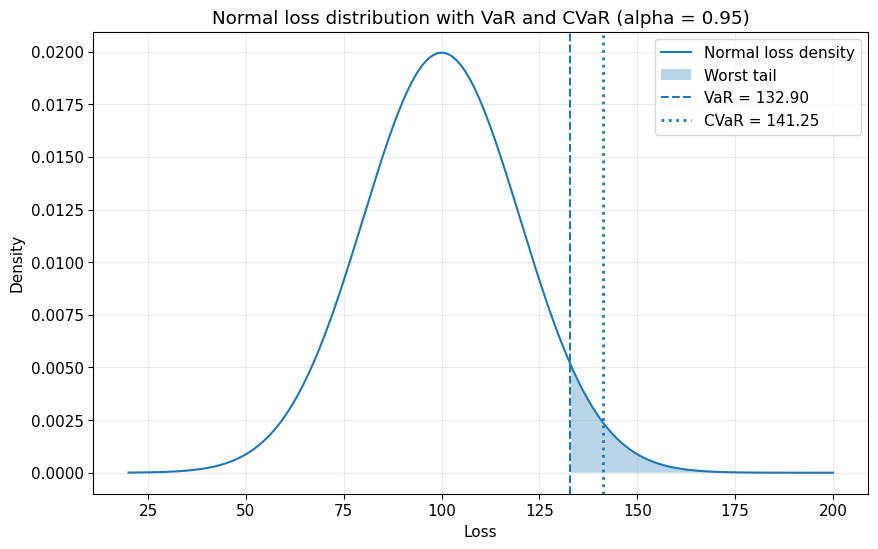

In [7]:
x = np.linspace(mu_normal - 4*sigma_normal, mu_normal + 5*sigma_normal, 1200)

def norm_pdf(x, mu=0.0, sigma=1.0, loc=None, scale=None):
    if loc is not None:
        mu = loc
    if scale is not None:
        sigma = scale
    x = np.asarray(x, dtype=float)
    z = (x - mu) / sigma
    return np.exp(-0.5 * z**2) / (sigma * np.sqrt(2 * np.pi))

pdf = norm_pdf(x, mu=mu_normal, sigma=sigma_normal)

fig, ax = plt.subplots()
ax.plot(x, pdf, label="Normal loss density")
ax.fill_between(x[x >= var_normal], pdf[x >= var_normal], alpha=0.3, label="Worst tail")
ax.axvline(var_normal, linestyle="--", label=f"VaR = {var_normal:.2f}")
ax.axvline(cvar_normal, linestyle=":", linewidth=2, label=f"CVaR = {cvar_normal:.2f}")
ax.set_title(f"Normal loss distribution with VaR and CVaR (alpha = {alpha_normal:.2f})")
ax.set_xlabel("Loss")
ax.set_ylabel("Density")
ax.legend()
plt.show()

## 2. Newsvendor setup: seasonal battery backup kits

Chapter 4 uses the mismatch loss

\[
L(Q,D) = C_o (Q-D)^+ + C_u (D-Q)^+,
\]

with

\[
C_o = c-v, \qquad C_u = p-c.
\]

Demand is assumed normal in the base example.

### 2A. Parameters

In [8]:
# Battery backup kit example
mu_demand = 1200
sigma_demand = 420

p = 980
c = 620
v = 390

alpha_nv = 0.95

C_u = p - c
C_o = c - v

params_nv = {
    "mu_demand": mu_demand,
    "sigma_demand": sigma_demand,
    "p": p,
    "c": c,
    "v": v,
    "C_u": C_u,
    "C_o": C_o,
    "alpha": alpha_nv,
}
display_series("Newsvendor parameters", params_nv)

Newsvendor parameters
mu_demand       1200.00
sigma_demand     420.00
p                980.00
c                620.00
v                390.00
C_u              360.00
C_o              230.00
alpha              0.95


### 2B. Helper functions

In [9]:
def loss_newsvendor(Q, D, C_o, C_u):
    D = np.asarray(D)
    return C_o * np.maximum(Q - D, 0) + C_u * np.maximum(D - Q, 0)

def profit_newsvendor(Q, D, p, c, v):
    D = np.asarray(D)
    sales = np.minimum(D, Q)
    leftover = np.maximum(Q - D, 0)
    return p * sales + v * leftover - c * Q

def expected_loss_normal(Q, mu, sigma, C_o, C_u):
    z = (Q - mu) / sigma
    return (
        C_o * ((Q - mu) * norm_cdf(z) + sigma * norm_pdf(z))
        + C_u * (sigma * norm_pdf(z) + (mu - Q) * (1 - norm_cdf(z)))
    )

def expected_profit_monte_carlo(Q, mu, sigma, p, c, v, n=200_000, seed=42):
    rng = np.random.default_rng(seed)
    D = rng.normal(mu, sigma, size=n)
    return profit_newsvendor(Q, D, p, c, v).mean()

def critical_ratio(C_u, C_o):
    return C_u / (C_u + C_o)

def optimal_Q_expected_profit(mu, sigma, C_u, C_o):
    cr = critical_ratio(C_u, C_o)
    return mu + sigma * norm_ppf(cr)

def loss_cdf_newsvendor(ell, Q, mu, sigma, C_o, C_u):
    ell = np.asarray(ell)
    out = np.zeros_like(ell, dtype=float)
    mask = ell >= 0
    out[mask] = (
        norm_cdf((Q + ell[mask] / C_u - mu) / sigma)
        - norm_cdf((Q - ell[mask] / C_o - mu) / sigma)
    )
    return out if out.ndim else float(out)

def var_newsvendor(Q, alpha, mu, sigma, C_o, C_u):
    # lower bound
    lo = 0.0
    # high bound expanded until sign change
    hi = sigma * max(C_o, C_u) * 2
    f = lambda ell: loss_cdf_newsvendor(np.array([ell]), Q, mu, sigma, C_o, C_u)[0] - alpha
    while f(hi) < 0:
        hi *= 2
        if hi > 1e8:
            raise RuntimeError("Could not bracket VaR root.")
    return bisection_root(f, lo, hi)

def cvar_newsvendor(Q, alpha, mu, sigma, C_o, C_u):
    v_alpha = var_newsvendor(Q, alpha, mu, sigma, C_o, C_u)
    a = Q - v_alpha / C_o
    b = Q + v_alpha / C_u
    z_a = (a - mu) / sigma
    z_b = (b - mu) / sigma
    numerator = (
        C_o * ((Q - mu) * norm_cdf(z_a) + sigma * norm_pdf(z_a))
        + C_u * (sigma * norm_pdf(z_b) + (mu - Q) * (1 - norm_cdf(z_b)))
    )
    return numerator / (1 - alpha)

def mean_cvar_objective(Q, lam, alpha, mu, sigma, C_o, C_u):
    return expected_loss_normal(Q, mu, sigma, C_o, C_u) + lam * cvar_newsvendor(Q, alpha, mu, sigma, C_o, C_u)

def optimize_mean_cvar(lam, alpha, mu, sigma, C_o, C_u, q_bounds=None):
    if q_bounds is None:
        q_bounds = (max(0, mu - 4*sigma), mu + 4*sigma)
    res = minimize_scalar(
        lambda Q: mean_cvar_objective(Q, lam, alpha, mu, sigma, C_o, C_u),
        bounds=q_bounds,
        method="bounded",
        options={"xatol": 1e-3},
    )
    return res.x, res.fun

## 3. The critical ratio and the risk-neutral benchmark

### 3A. Compute the critical ratio and the expected-profit / expected-loss optimum

In [10]:
cr = critical_ratio(C_u, C_o)
Q_EP = optimal_Q_expected_profit(mu_demand, sigma_demand, C_u, C_o)

benchmark = {
    "critical_ratio": cr,
    "Q_EP": Q_EP,
    "Expected_loss_at_Q_EP": expected_loss_normal(Q_EP, mu_demand, sigma_demand, C_o, C_u),
}
display_series("Risk-neutral benchmark", benchmark)

Risk-neutral benchmark
critical_ratio               0.610169
Q_EP                      1317.499542
Expected_loss_at_Q_EP    95064.002877


### 3B. Plot expected profit and expected loss against the order quantity

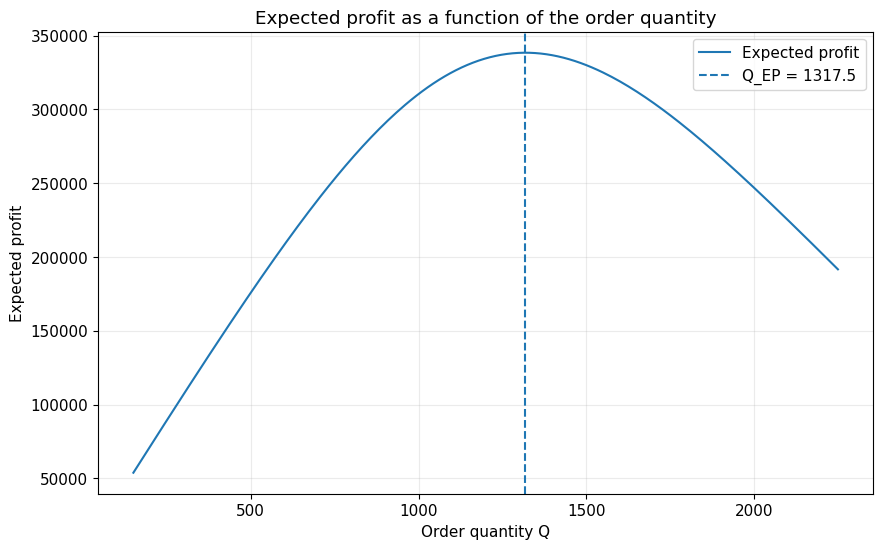

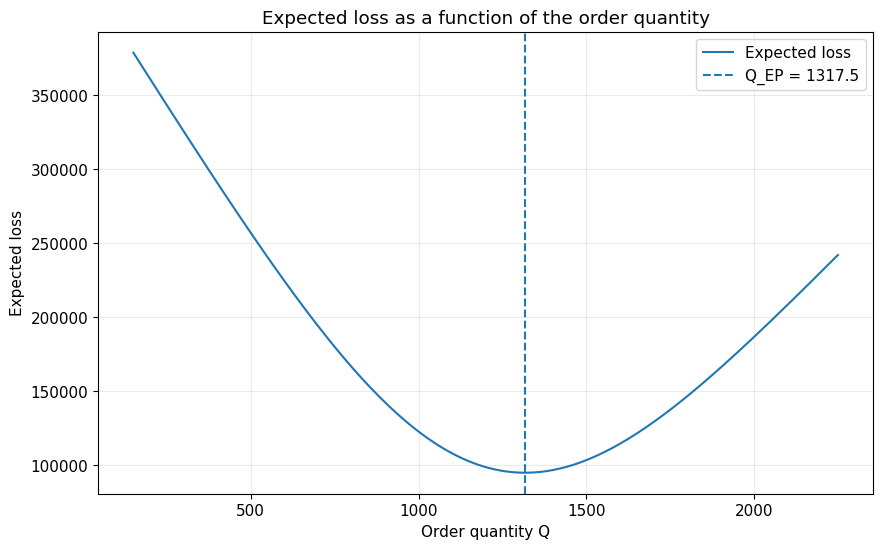

In [11]:
Q_grid = np.linspace(max(0, mu_demand - 2.5*sigma_demand), mu_demand + 2.5*sigma_demand, 250)

# Expected loss has closed form
exp_loss_vals = np.array([expected_loss_normal(Q, mu_demand, sigma_demand, C_o, C_u) for Q in Q_grid])

# Expected profit can be written from loss up to an additive / affine transformation:
# E[profit] = (p-c)E[D] - expected underage/overage structure up to constants.
# For transparency, compute directly by numerical integration over a dense grid.
D_grid = np.linspace(max(0, mu_demand - 5*sigma_demand), mu_demand + 5*sigma_demand, 5000)
pdf_D = norm_pdf(D_grid, loc=mu_demand, scale=sigma_demand)
pdf_D /= np.trapz(pdf_D, D_grid)

exp_profit_vals = []
for Q in Q_grid:
    profits = profit_newsvendor(Q, D_grid, p, c, v)
    exp_profit_vals.append(np.trapz(profits * pdf_D, D_grid))
exp_profit_vals = np.array(exp_profit_vals)

fig, ax = plt.subplots()
ax.plot(Q_grid, exp_profit_vals, label="Expected profit")
ax.axvline(Q_EP, linestyle="--", label=f"Q_EP = {Q_EP:.1f}")
ax.set_title("Expected profit as a function of the order quantity")
ax.set_xlabel("Order quantity Q")
ax.set_ylabel("Expected profit")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(Q_grid, exp_loss_vals, label="Expected loss")
ax.axvline(Q_EP, linestyle="--", label=f"Q_EP = {Q_EP:.1f}")
ax.set_title("Expected loss as a function of the order quantity")
ax.set_xlabel("Order quantity Q")
ax.set_ylabel("Expected loss")
ax.legend()
plt.show()

## 4. VaR and CVaR of the induced newsvendor loss

For each order quantity \(Q\), the induced loss distribution is not normal even when demand is normal.

This section computes:

- \(\mathrm{VaR}_\alpha(L_Q)\) numerically from the induced loss CDF,
- \(\mathrm{CVaR}_\alpha(L_Q)\) from the tail-expectation formula,

and plots them over the order-quantity range used for the chapter figure.

### 4A. Parameters for policy evaluation

In [12]:
alpha_eval = alpha_nv
Q_eval = Q_EP

# Order-quantity range used for the chapter-style plot
q_min_fig = 400
q_max_fig = 2200

### 4B. Evaluate VaR and CVaR at a chosen order quantity

In [13]:
var_eval = var_newsvendor(Q_eval, alpha_eval, mu_demand, sigma_demand, C_o, C_u)
cvar_eval = cvar_newsvendor(Q_eval, alpha_eval, mu_demand, sigma_demand, C_o, C_u)

evaluation_summary = {
    "Q_eval": Q_eval,
    "alpha_eval": alpha_eval,
    "VaR_alpha(L_Q)": var_eval,
    "CVaR_alpha(L_Q)": cvar_eval,
}
display_series("Policy evaluation at selected Q", evaluation_summary)

Policy evaluation at selected Q
Q_eval               1317.499542
alpha_eval              0.950000
VaR_alpha(L_Q)     233883.967209
CVaR_alpha(L_Q)    285383.694349


### 4C. Plot VaR and CVaR as functions of the order quantity

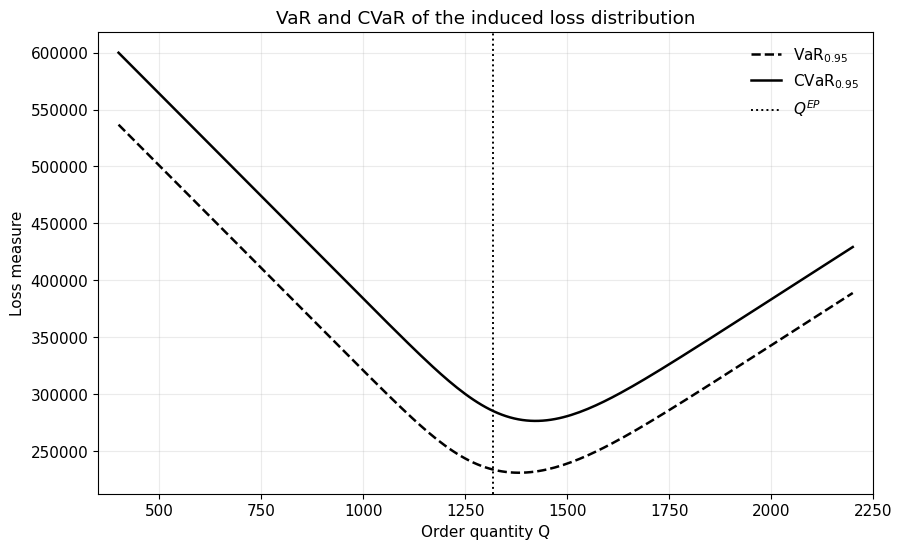

In [14]:
Q_grid_risk = np.linspace(q_min_fig, q_max_fig, 181)
var_vals = np.array([var_newsvendor(Q, alpha_eval, mu_demand, sigma_demand, C_o, C_u) for Q in Q_grid_risk])
cvar_vals = np.array([cvar_newsvendor(Q, alpha_eval, mu_demand, sigma_demand, C_o, C_u) for Q in Q_grid_risk])

fig, ax = plt.subplots()
ax.plot(Q_grid_risk, var_vals, label=r"VaR$_{0.95}$", **BW_STYLES["dashed"])
ax.plot(Q_grid_risk, cvar_vals, label=r"CVaR$_{0.95}$", **BW_STYLES["solid"])
ax.axvline(Q_EP, label=r"$Q^{EP}$", **BW_STYLES["dotted"])

ax.set_title("VaR and CVaR of the induced loss distribution")
ax.set_xlabel("Order quantity Q")
ax.set_ylabel("Loss measure")
ax.set_xlim(q_min_fig - 50, q_max_fig + 50)
ax.legend(frameon=False)
plt.show()

### 4D. Plot the loss function against realized demand for selected policies

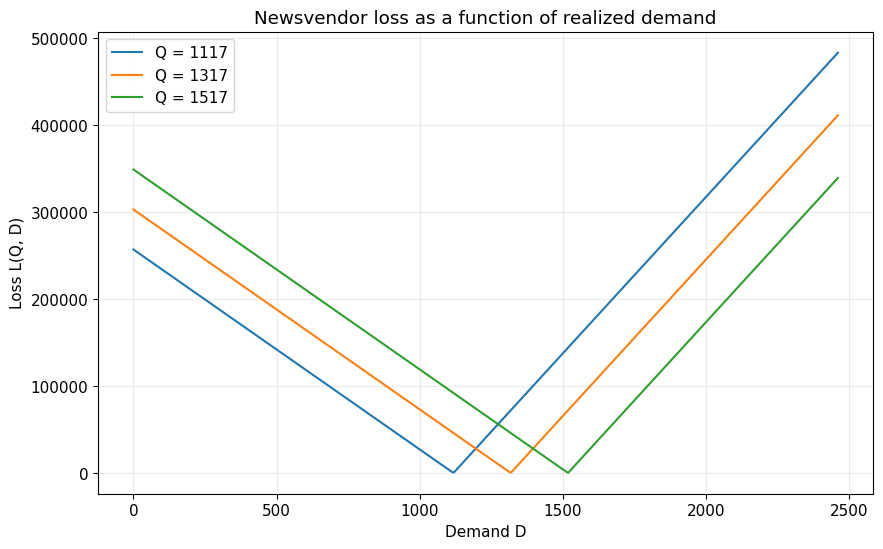

In [15]:
selected_Q = [Q_EP - 200, Q_EP, Q_EP + 200]
D_plot = np.linspace(max(0, mu_demand - 3*sigma_demand), mu_demand + 3*sigma_demand, 500)

fig, ax = plt.subplots()
for Q in selected_Q:
    ax.plot(D_plot, loss_newsvendor(Q, D_plot, C_o, C_u), label=f"Q = {Q:.0f}")
ax.set_title("Newsvendor loss as a function of realized demand")
ax.set_xlabel("Demand D")
ax.set_ylabel("Loss L(Q, D)")
ax.legend()
plt.show()

## 5. Mean--CVaR optimization

We now move from **policy evaluation** to **policy choice** and study

\[
E[L(Q,D)] + \lambda \, \mathrm{CVaR}_{\alpha}(L_Q).
\]

The default plot settings below are chosen to align more closely with the chapter figure.

### 5A. Parameters for optimization

Edit these values only if you want a different figure.  
To reproduce the chapter-style plot, keep the default values below.

In [17]:
lambda_values = [0.0, 0.2, 0.5, 1.0]
alpha_opt = 0.95
q_bounds = (400, 2200)

### 5B. Plot the mean--CVaR objective for different values of lambda

This cell reproduces the chapter-style comparison across different values of \(\lambda\).

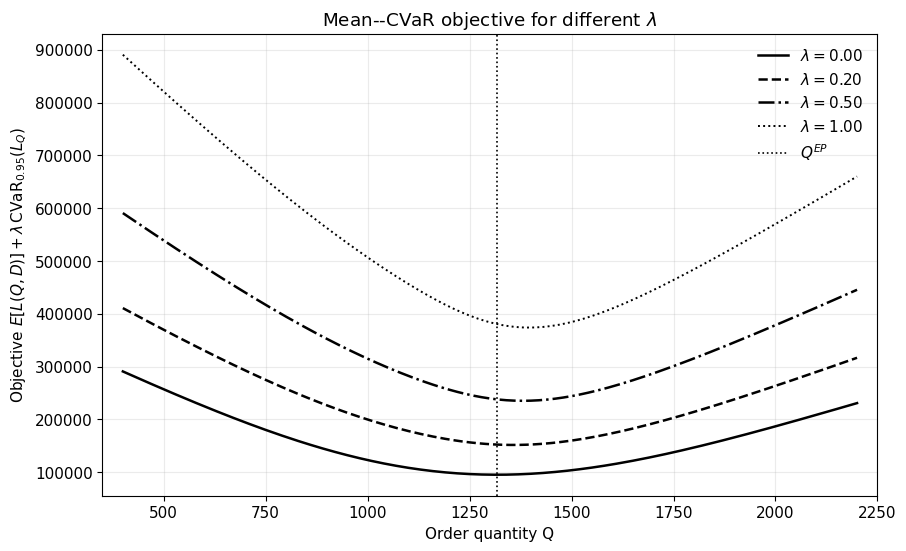

In [18]:
Q_grid_obj = np.linspace(q_bounds[0], q_bounds[1], 181)
line_styles = [
    BW_STYLES["solid"],
    BW_STYLES["dashed"],
    BW_STYLES["dashdot"],
    BW_STYLES["dotted"],
]

fig, ax = plt.subplots()
for lam, style in zip(lambda_values, line_styles):
    obj_vals = np.array([mean_cvar_objective(Q, lam, alpha_opt, mu_demand, sigma_demand, C_o, C_u) for Q in Q_grid_obj])
    ax.plot(Q_grid_obj, obj_vals, label=rf"$\lambda = {lam:.2f}$", **style)

ax.axvline(Q_EP, label=r"$Q^{EP}$", color="black", linestyle=":", linewidth=1.2)
ax.set_title(r"Mean--CVaR objective for different $\lambda$")
ax.set_xlabel("Order quantity Q")
ax.set_ylabel(r"Objective $E[L(Q,D)] + \lambda\,\mathrm{CVaR}_{0.95}(L_Q)$")
ax.set_xlim(q_bounds[0] - 50, q_bounds[1] + 50)
ax.legend(frameon=False)
plt.show()

### 5C. Compute the optimal order quantity for each lambda

In [22]:
rows = []
for lam in lambda_values:
    q_star, obj_star = optimize_mean_cvar(lam, alpha_opt, mu_demand, sigma_demand, C_o, C_u, q_bounds=q_bounds)
    rows.append({"lambda": lam, "Q_star": q_star, "objective": obj_star})

opt_lambda_df = pd.DataFrame(rows)
opt_lambda_df

,lambda,Q_star,objective
0,0.0,1317.499408,95064.002877
1,0.2,1357.081567,151468.389354
2,0.5,1380.572988,235077.662686
3,1.0,1396.073175,373779.424207


### 5D. Plot the optimal order quantity against lambda

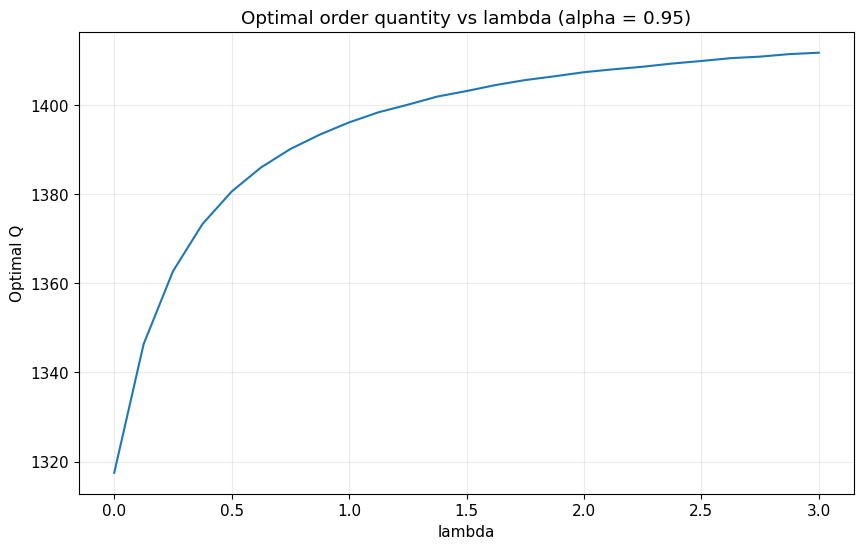

In [23]:
lambda_grid = np.linspace(0, 3, 25)
q_star_lambda = [optimize_mean_cvar(lam, alpha_opt, mu_demand, sigma_demand, C_o, C_u, q_bounds=q_bounds)[0] for lam in lambda_grid]

fig, ax = plt.subplots()
ax.plot(lambda_grid, q_star_lambda)
ax.set_title(f"Optimal order quantity vs lambda (alpha = {alpha_opt:.2f})")
ax.set_xlabel("lambda")
ax.set_ylabel("Optimal Q")
plt.show()

## 6. Sensitivity analysis in alpha

This section keeps \(\lambda\) fixed and shows how the objective changes as the confidence level \(\alpha\) changes.

### 6A. Parameters

The default values below match the chapter-style comparison figure.

In [24]:
lambda_alpha = 1.0
alpha_values = [0.90, 0.95, 0.975, 0.99]

### 6B. Plot the objective for different values of alpha

This cell plots the mean--CVaR objective across different confidence levels while holding \(\lambda = 1\).

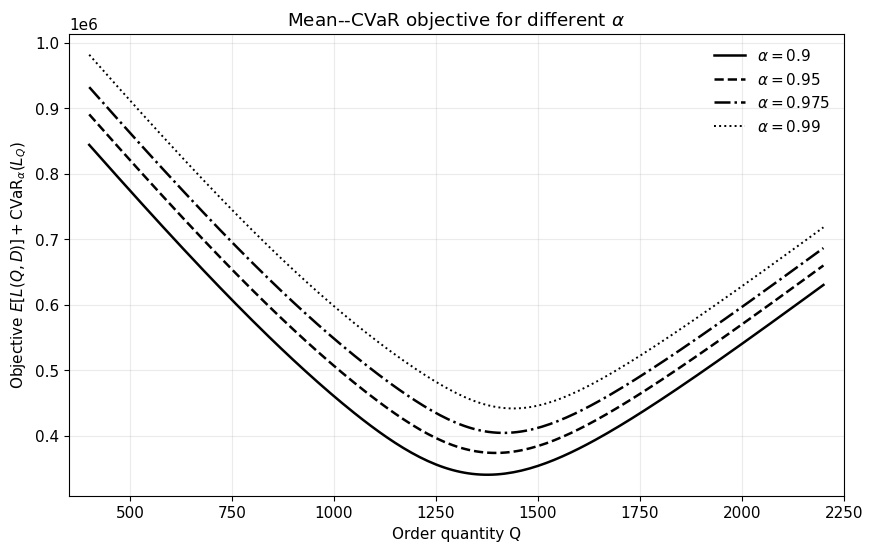

In [25]:
alpha_styles = [
    BW_STYLES["solid"],
    BW_STYLES["dashed"],
    BW_STYLES["dashdot"],
    BW_STYLES["dotted"],
]

fig, ax = plt.subplots()
for alpha, style in zip(alpha_values, alpha_styles):
    obj_vals = np.array([mean_cvar_objective(Q, lambda_alpha, alpha, mu_demand, sigma_demand, C_o, C_u) for Q in Q_grid_obj])
    ax.plot(Q_grid_obj, obj_vals, label=rf"$\alpha = {alpha}$", **style)

ax.set_title(r"Mean--CVaR objective for different $\alpha$")
ax.set_xlabel("Order quantity Q")
ax.set_ylabel(r"Objective $E[L(Q,D)] + \mathrm{CVaR}_{\alpha}(L_Q)$")
ax.set_xlim(q_bounds[0] - 50, q_bounds[1] + 50)
ax.legend(frameon=False)
plt.show()

### 6C. Compute the optimal order quantity for each alpha

In [26]:
rows = []
for alpha in alpha_values:
    q_star, obj_star = optimize_mean_cvar(lambda_alpha, alpha, mu_demand, sigma_demand, C_o, C_u, q_bounds=q_bounds)
    rows.append({"alpha": alpha, "Q_star": q_star, "objective": obj_star})

opt_alpha_df = pd.DataFrame(rows)
opt_alpha_df

,alpha,Q_star,objective
0,0.900,1376.094602,340509.182166
1,0.950,1396.073175,373779.424207
2,0.975,1415.349005,404373.174499
3,0.990,1439.509193,441687.492860


### 6D. Plot the optimal order quantity against alpha

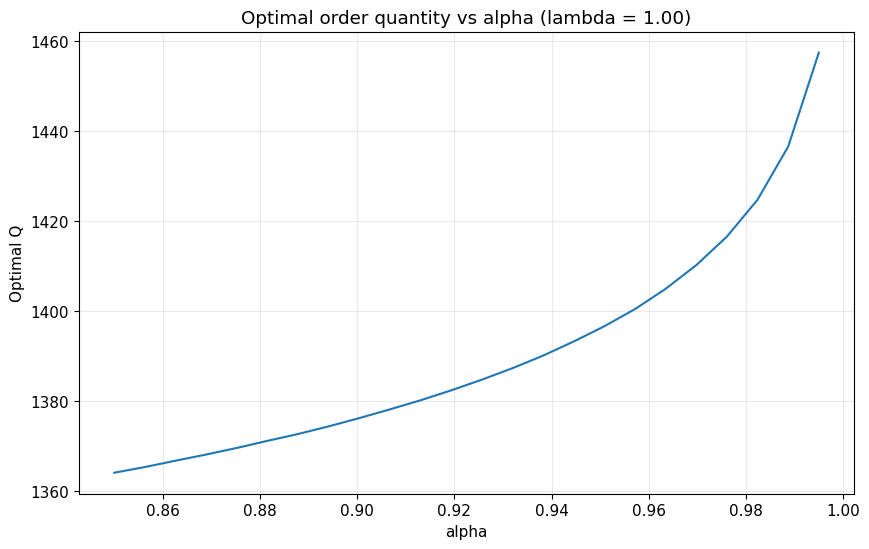

In [27]:
alpha_grid = np.linspace(0.85, 0.995, 24)
q_star_alpha = [optimize_mean_cvar(lambda_alpha, alpha, mu_demand, sigma_demand, C_o, C_u, q_bounds=q_bounds)[0] for alpha in alpha_grid]

fig, ax = plt.subplots()
ax.plot(alpha_grid, q_star_alpha)
ax.set_title(f"Optimal order quantity vs alpha (lambda = {lambda_alpha:.2f})")
ax.set_xlabel("alpha")
ax.set_ylabel("Optimal Q")
plt.show()

## 7. Optional validation by Monte Carlo simulation

This section checks the analytic formulas numerically by simulation.

In [28]:
# Monte Carlo validation at Q_EP
rng = np.random.default_rng(123)
D_sim = rng.normal(mu_demand, sigma_demand, size=400_000)
L_sim = loss_newsvendor(Q_EP, D_sim, C_o, C_u)

var_mc = np.quantile(L_sim, alpha_nv)
cvar_mc = L_sim[L_sim >= var_mc].mean()

validation = pd.DataFrame({
    "Measure": ["VaR analytic", "VaR Monte Carlo", "CVaR analytic", "CVaR Monte Carlo"],
    "Value": [
        var_newsvendor(Q_EP, alpha_nv, mu_demand, sigma_demand, C_o, C_u),
        var_mc,
        cvar_newsvendor(Q_EP, alpha_nv, mu_demand, sigma_demand, C_o, C_u),
        cvar_mc,
    ],
})
validation

,Measure,Value
0,VaR analytic,233883.967209
1,VaR Monte Carlo,234027.797060
2,CVaR analytic,285383.694349
3,CVaR Monte Carlo,285034.779966


## 8. Key takeaway table

In [29]:
key_takeaways = pd.DataFrame({
    "Concept": [
        "Normal-loss VaR",
        "Normal-loss CVaR",
        "Critical ratio",
        "Risk-neutral quantity",
        "Newsvendor induced VaR",
        "Newsvendor induced CVaR",
        "Mean--CVaR optimum",
    ],
    "Interpretation": [
        "Quantile threshold for a normal loss variable",
        "Average loss in the tail beyond VaR",
        "Balances underage and overage costs",
        "Expected-profit-maximizing / expected-loss-minimizing quantity",
        "Threshold of the worst tail losses induced by a chosen Q",
        "Average loss inside that induced tail",
        "Tail-sensitive optimal order quantity",
    ],
})
key_takeaways

,Concept,Interpretation
0,Normal-loss VaR,Quantile threshold for a normal loss variable
1,Normal-loss CVaR,Average loss in the tail beyond VaR
2,Critical ratio,Balances underage and overage costs
3,Risk-neutral quantity,Expected-profit-maximizing / expected-loss-min...
4,Newsvendor induced VaR,Threshold of the worst tail losses induced by ...
5,Newsvendor induced CVaR,Average loss inside that induced tail
6,Mean--CVaR optimum,Tail-sensitive optimal order quantity


## 9. Notes

- If you see a `NameError`, restart the kernel and run the notebook from the top.
- If you see an import error, confirm that the notebook is using the project `.venv` kernel rather than the system Python.
- The plotting ranges in Sections 4, 5, and 6 are chosen to resemble the chapter figures more closely.
- The code can be adapted to other one-period stochastic decision problems with asymmetric loss.